# Changes

> Utils to monitor and report changes to domain experts across iterations (prompt, pipeline, ...)


In [ ]:
#| default_exp llm_eval.changes

In [ ]:
#| export
import json
from fastcore.all import *
from iomeval.readers import load_evals
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patheffects import withStroke
from dialoghelper.stdtools import *

pd.set_option('display.max_colwidth', None)

## Setup

In [ ]:
#| eval: false
ROOT_PATH = Path.home() / 'iomeval'
DATA_PATH = ROOT_PATH / 'data'
RESULTS_PATH = DATA_PATH/ 'results'
EVALS_PATH = ROOT_PATH / 'nbs/files/test/evaluations.json'

# Contains latest backed up data before new deployment
LATEST_TAG_PATH = Path.home() / 'tagapp/backups/20260311_115159/data'

evals = load_evals(EVALS_PATH)

In [ ]:
#| eval: false
# Reports requested by IOM CED evaluators for assessment
lut = (Path().home() / 'iomeval/data/requester_by_report_id.json').read_json()
evls_test = L(lut.keys())
evls_test[:2]

['4341695461234eee3deb51ac68871109', '6c3c2cf3fa479112967612b0baddab72']

In [ ]:
#| eval: false
# To be used for usage examples below
evl = evls_test[0]; evl

'4341695461234eee3deb51ac68871109'

## Utils

In [ ]:
#| export
def get_deployed_ids(
    dir:Path # source directory 
    ):
    "List of report IDs currently deployed (from tagapp backup)"
    return Path(dir).ls(file_exts='.json').map(lambda p: p.stem)

In [ ]:
#| eval: false
get_deployed_ids(LATEST_TAG_PATH)[:2]

['8dd2261100ff5d714e73b411eed043d5', '1d7e6d2d445145d1d350b48b72b36681']

In [ ]:
#| export
def load_result(
    eval_id: str, # evaluation report id 
    dir: Path # path to directory containing results `.json` files
    ):
    "Load a result JSON by eval_id from base_path"
    return (Path(dir)/f'{eval_id}.json').read_json()


For instance:

In [ ]:
#| eval: false
r = load_result('8dd2261100ff5d714e73b411eed043d5', RESULTS_PATH);
print(r.keys()), print(r['mappings'].keys());

dict_keys(['id', 'report_url', 'meta', 'docs', 'curation_status', 'selected_headings', 'mappings', 'timestamp'])
dict_keys(['enbs', 'ccps', 'gcms', 'outs'])


In [ ]:
#| export
def is_remapped(
    eval_id, # evaluation report id
    dir_new, # path to current results
    dir_old # path to backup results
    ):
    "Check if report mappings differ between current results and deployed backup"
    current = load_result(eval_id, dir_new)
    deployed = load_result(eval_id, dir_old)
    return current.get('mappings') != deployed.get('mappings')

For instance:

In [ ]:
#| eval: false
is_remapped('8dd2261100ff5d714e73b411eed043d5', DATA_PATH/'results', LATEST_TAG_PATH)

True

In [ ]:
#| export
def info_evl(
    evl_id # evaluation report id
    ): 
    "Return information about an evaluation"
    return first([o for o in evals if o.id == evl_id])

In [ ]:
#| eval: false
info_evl('0d4309b702e00faac631be8d609934ce')


### Fifth Evaluation of the IOM Development Fund
**Year:** 2025 | **Organization:** IOM | **Countries:** Worldwide

**Documents:** 5 available  
**ID:** `0d4309b702e00faac631be8d609934ce`


## Data processing

In [ ]:
#| export
def mappings2df(
    evl_id:str,  # evaluation ID
    data_path:Path,  # path to results data
) -> pd.DataFrame:  # one row per (mapping_type, theme)
    "Flatten a result's mappings into a DataFrame."
    result = load_result(evl_id, data_path)
    rows = [dict(mapping_type=mt, theme_id=m['theme_id'], theme_title=m['theme_title'], score=m['relevance_score'])
            for mt,maps in result.get('mappings', {}).items() for m in maps]
    return pd.DataFrame(rows)

For instance:

In [ ]:
#| eval: false
print(mappings2df(evl, RESULTS_PATH).head())

  mapping_type theme_id              theme_title  score
0         enbs        1                Workforce   0.42
1         enbs        2              Partnership   0.72
2         enbs        3                  Funding   0.38
3         enbs        4        Data and evidence   0.18
4         enbs        5  Learning and Innovation   0.45


In [ ]:
#| export
def delta_df(
    evl_id:str,   # evaluation ID
    base_path:Path,   # path to new results
    backup_path:Path, # path to old results
) -> pd.DataFrame: # merged DataFrame with score_old/score_new
    "Compare old and new mappings for a report."
    old = mappings2df(evl_id, backup_path).rename(columns=dict(score='score_old'))
    new = mappings2df(evl_id, base_path).rename(columns=dict(score='score_new'))
    return old.merge(new, on=['mapping_type','theme_id'], how='outer')

For instance:

In [ ]:
#| eval: false
print(delta_df(evl, RESULTS_PATH, LATEST_TAG_PATH).head())

  mapping_type theme_id                               theme_title_x  \
0         ccps        1  Integrity, Transparency and Accountability   
1         ccps        2             Equality, Diversity & Inclusion   
2         ccps        3                          Protection-centred   
3         ccps        4                Environmental Sustainability   
4         enbs        1                                   Workforce   

   score_old                               theme_title_y  score_new  
0       0.48  Integrity, Transparency and Accountability       0.52  
1       0.38             Equality, Diversity & Inclusion       0.30  
2       0.72                          Protection-centred       0.66  
3       0.12                Environmental Sustainability       0.05  
4       0.48                                   Workforce       0.42  


In [ ]:
#| eval: false
delta_df(evl, RESULTS_PATH, LATEST_TAG_PATH).query("mapping_type=='gcms' and theme_id=='23'")

,mapping_type,theme_id,theme_title_x,score_old,theme_title_y,score_new
26,gcms,23,"Strengthen International Cooperation And Global Partnerships For Safe, Orderly And Regular Migration",0.72,"Strengthen international cooperation and global partnerships for safe, orderly and regular migration",0.2


### Transforms

In [ ]:
#| export
def add_diffs(
    df: pd.DataFrame # dataframe to transform
    ):
    "Add score_diff and new/dropped flags to a comparison DataFrame"
    return df.assign(score_diff=df.score_new - df.score_old, is_new=df.score_old.isna(), is_dropped=df.score_new.isna())

In [ ]:
#| export
def add_ranks(
    df: pd.DataFrame # dataframe to transform
    ):
    "Add old/new ranks (within each mapping_type, descending score) and rank_diff"
    df = df.copy()
    df['rank_old'] = df.groupby('mapping_type')['score_old'].rank(ascending=False, method='dense').astype('Int64')
    df['rank_new'] = df.groupby('mapping_type')['score_new'].rank(ascending=False, method='dense').astype('Int64')
    df['rank_diff'] = df['rank_old'] - df['rank_new']
    return df

In [ ]:
#| export
def add_pct_change(
    df, # dataframe to transform
    min_score=0.05 # minimum score to consider for pct change calculations
    ):
    "Add percentage change, treating old scores below min_score as NaN to avoid division noise"
    safe_old = df.score_old.where(df.score_old >= min_score)
    return df.assign(pct_change=(df.score_new - df.score_old) / safe_old * 100)

For instance:

In [ ]:
#| eval: false
df = delta_df(evl, RESULTS_PATH, LATEST_TAG_PATH).pipe(add_diffs).pipe(add_ranks).pipe(add_pct_change)

In [ ]:
#| eval: false
df.head()

,mapping_type,theme_id,theme_title_x,score_old,theme_title_y,score_new,score_diff,is_new,is_dropped,rank_old,rank_new,rank_diff,pct_change
0,ccps,1,"Integrity, Transparency and Accountability",0.48,"Integrity, Transparency and Accountability",0.52,0.04,False,False,2,2,0,8.333333
1,ccps,2,"Equality, Diversity & Inclusion",0.38,"Equality, Diversity & Inclusion",0.30,-0.08,False,False,3,3,0,-21.052632
2,ccps,3,Protection-centred,0.72,Protection-centred,0.66,-0.06,False,False,1,1,0,-8.333333
3,ccps,4,Environmental Sustainability,0.12,Environmental Sustainability,0.05,-0.07,False,False,4,4,0,-58.333333
4,enbs,1,Workforce,0.48,Workforce,0.42,-0.06,False,False,4,4,0,-12.500000


In [ ]:
df.sort_values('score_diff', key=abs, ascending=False).head(5)

,mapping_type,theme_id,theme_title_x,score_old,theme_title_y,score_new,score_diff,is_new,is_dropped,rank_old,rank_new,rank_diff,pct_change
26,gcms,23,"Strengthen International Cooperation And Global Partnerships For Safe, Orderly And Regular Migration",0.72,"Strengthen international cooperation and global partnerships for safe, orderly and regular migration",0.20,-0.52,False,False,5,11,-6,-72.222222
23,gcms,20,Minimize the adverse drivers and structural factors that compel people to leave their country of origin,0.35,"Promote faster, safer and cheaper transfer of remittances and foster financial inclusion of migrants",0.05,-0.30,False,False,10,16,-6,-85.714286
7,enbs,4,Data and evidence,0.38,Data and evidence,0.18,-0.20,False,False,6,6,0,-52.631579
6,enbs,3,Funding,0.55,Funding,0.38,-0.17,False,False,3,5,-2,-30.909091
27,gcms,3,Provide accurate and timely information at all stages of migration,0.52,Provide accurate and timely information at all stages of migration,0.35,-0.17,False,False,7,6,1,-32.692308


### All evaluations processed

In [ ]:
#| export
def all_deltas(
    evl_ids:list,  # evaluation IDs to compare
    dir_new:Path,   # path to new results
    dir_old:Path, # path to old results
) -> pd.DataFrame:  # combined DataFrame across all reports
    "Build a combined comparison DataFrame for multiple reports."
    return pd.concat([
        delta_df(d, dir_new, dir_old).pipe(add_diffs).pipe(add_ranks).pipe(add_pct_change).assign(evl_id=d)
        for d in evl_ids], ignore_index=True)

For instance:

In [ ]:
#| eval: false
dfs = all_deltas(evls_test, RESULTS_PATH, LATEST_TAG_PATH)

In [ ]:
#| eval: false
dfs.iloc[0]

mapping_type                                           ccps
theme_id                                                  1
theme_title_x    Integrity, Transparency and Accountability
score_old                                              0.48
theme_title_y    Integrity, Transparency and Accountability
score_new                                              0.52
score_diff                                             0.04
is_new                                                False
is_dropped                                            False
rank_old                                                  2
rank_new                                                  2
rank_diff                                                 0
pct_change                                         8.333333
evl_id                     4341695461234eee3deb51ac68871109
Name: 0, dtype: object

In [ ]:
#| eval: false
print(dfs[dfs.evl_id == '760568a15e144bcfb88dbbd50247dc51'][['mapping_type', 'theme_id', 'rank_old', 'rank_new', 'rank_diff']].query('mapping_type == "gcms"').head(14))

    mapping_type theme_id  rank_old  rank_new  rank_diff
533         gcms        1        14        13          1
534         gcms       10        16        14          2
535         gcms       11        17        18         -1
536         gcms       12        15        17         -2
537         gcms       13        21        20          1
538         gcms       14        18        16          2
539         gcms       15         8        10         -2
540         gcms       16         1         3         -2
541         gcms       17         9         6          3
542         gcms       18         6         4          2
543         gcms       19         3         1          2
544         gcms        2        13        12          1
545         gcms       20        13         8          5
546         gcms       21        12        15         -3


## Visualization

### Per eval

In [ ]:
#| export
#| eval: false
def plot_score_diffs_bar(
    df:pd.DataFrame # input DataFrame
    ):
    "Bar chart of score diffs (new − old) per theme, coloured by direction, faceted by mapping type"
    fig, axes = plt.subplots(1, df.mapping_type.nunique(), figsize=(20, 8), sharey=False)
    for ax, (mt, grp) in zip(axes, df.groupby('mapping_type')):
        ax.barh(grp.theme_id.astype(str), grp.score_diff, color=['#d9534f' if x > 0 else 'steelblue' for x in grp.score_diff])
        ax.axvline(0, color='black', linewidth=0.8)
        ax.set(title=mt, xlabel='Score diff', ylabel='Theme ID')
    plt.tight_layout()
    plt.show()

For instance:

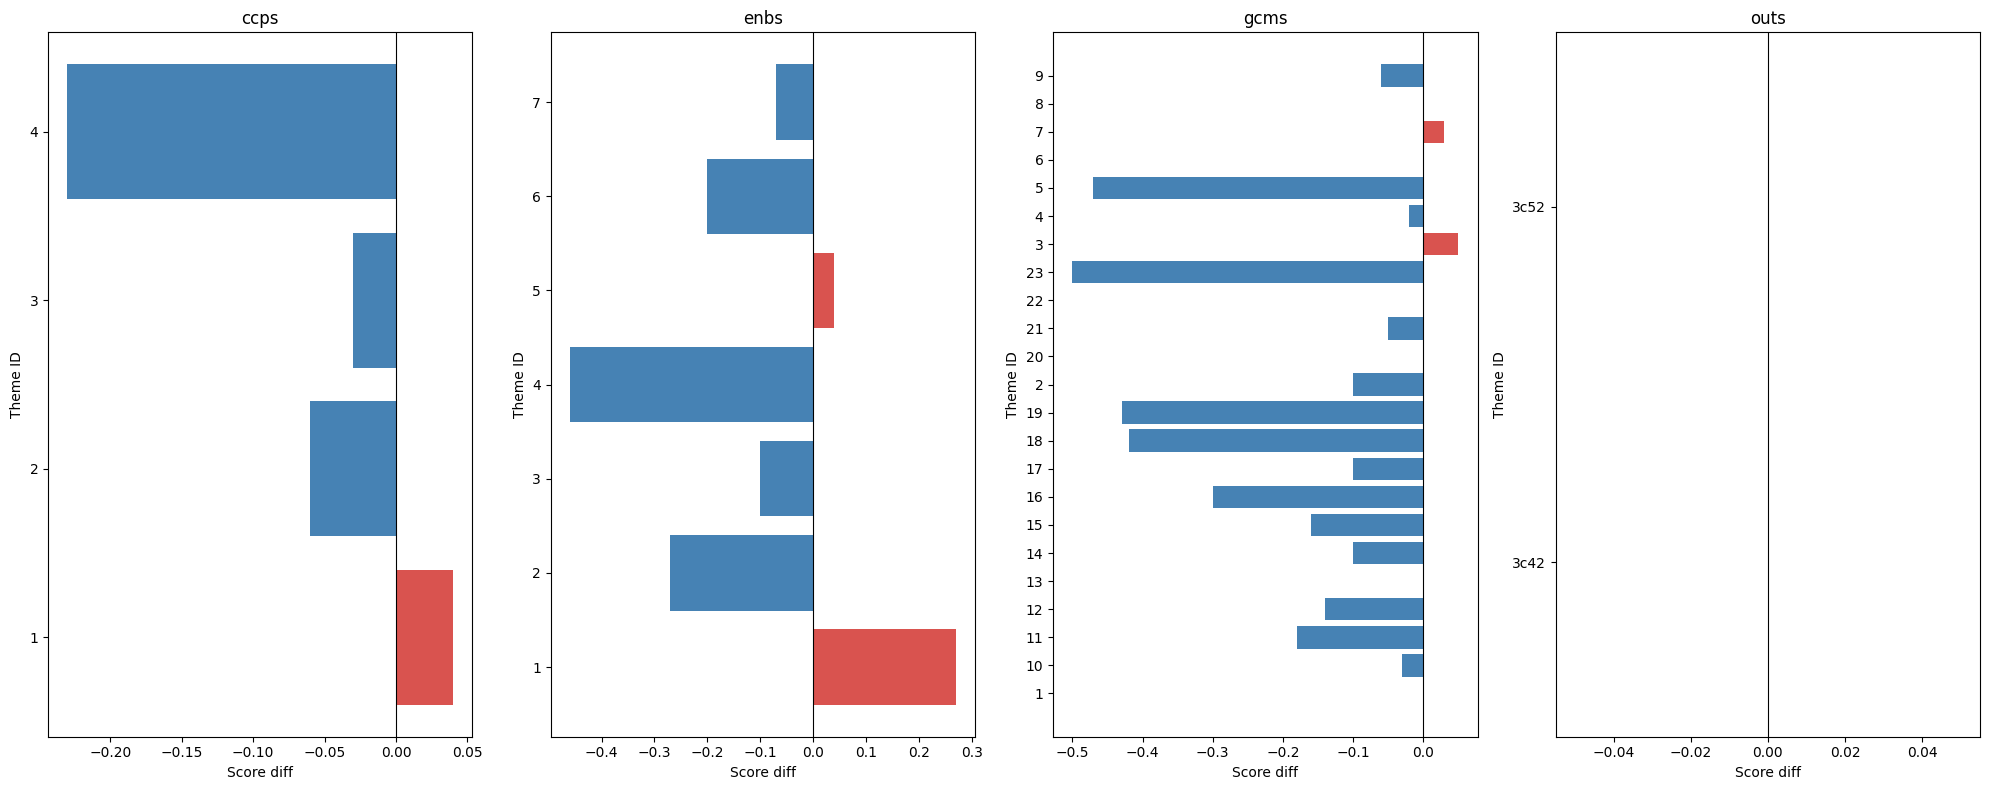

In [ ]:
#| eval: false
plot_score_diffs_bar(dfs[dfs.evl_id == '0d4309b702e00faac631be8d609934ce'])

In [ ]:
#| export
#| eval: false
def plot_rank_changes(
    df:pd.DataFrame, # input DataFrame
    **kwargs # passed to plt.subplots (e.g. figsize, dpi)
    ):
    "Slope chart of rank changes (old → new) per mapping type, coloured by direction"
    fig, axes = plt.subplots(1, df.mapping_type.nunique(), sharey=False, **kwargs)
    for ax, (mt, grp) in zip(axes, df.groupby('mapping_type')):
        for _, row in grp.iterrows():
            color = 'steelblue' if row.rank_diff < 0 else '#d9534f' if row.rank_diff > 0 else 'grey'
            ax.plot([0, 1], [row.rank_old, row.rank_new], marker='o', color=color, alpha=0.7)
            ax.text(0.5, (row.rank_old + row.rank_new) / 2 + (-0.15 * row.rank_diff), row.theme_id,
                    ha='center', va='center', fontsize=8, fontweight='bold', color=color,
                    path_effects=[withStroke(linewidth=3, foreground='white')])
        ax.set_xticks([0, 1])
        ax.set_xticklabels(['Old', 'New'], fontsize=12)
        ax.invert_yaxis()
        ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
        ax.set_title(mt, fontsize=14, fontweight='normal')
        ax.set_ylabel('Rank', fontsize=12)
    plt.tight_layout()
    plt.show()

For instance:

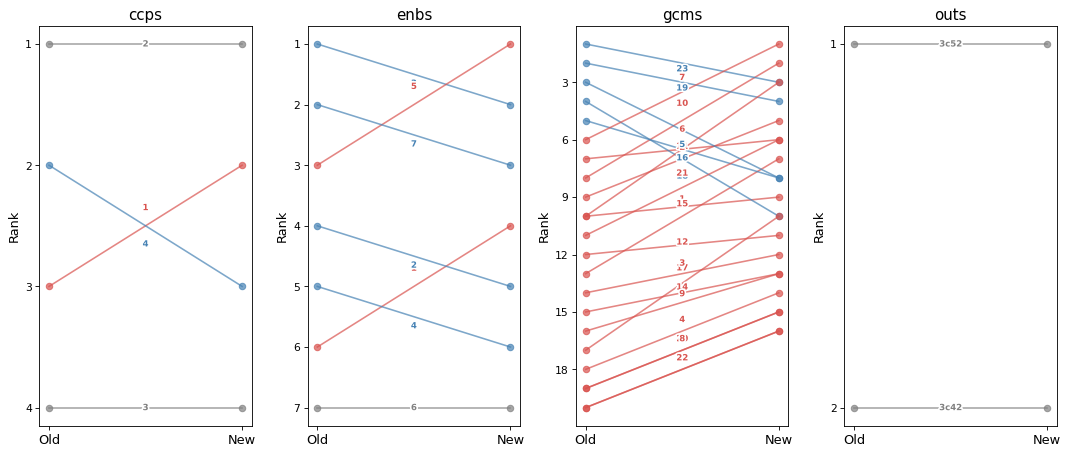

In [ ]:
#| eval: false
plot_rank_changes(dfs[dfs.evl_id == '0d4309b702e00faac631be8d609934ce'], figsize=(14, 6), dpi=77)

### All

In [ ]:
#| export
def plot_score_diffs(
    dfs: pd.DataFrame, # DataFrame of deltas from all_deltas 
    mapping_type, # mapping type to plot (gcms, enbs, ...)
    xlabel='Theme', # x-axis label
    col='score_diff', # column to plot
    **kwargs # passed to plt.subplots (e.g. figsize, dpi)
    ):
    "Violin plot of score diffs (new − old) per theme for a given mapping type"
    d = dfs[dfs.mapping_type==mapping_type].copy()
    d['theme_id'] = d['theme_id'].astype(int)
    d = d.sort_values('theme_id')
    f, ax = plt.subplots(**kwargs)
    sns.violinplot(data=d, x='theme_id', y=col, hue='theme_id', legend=False, bw_adjust=.5, cut=1, linewidth=1, palette="Set3")
    ax.axhline(0, color='red', linewidth=0.8, linestyle='--')
    ax.set(xlabel=xlabel, ylabel=f'{col} (new − old)', title=mapping_type)
    sns.despine(left=True, bottom=True)
    plt.tight_layout()

For instance:

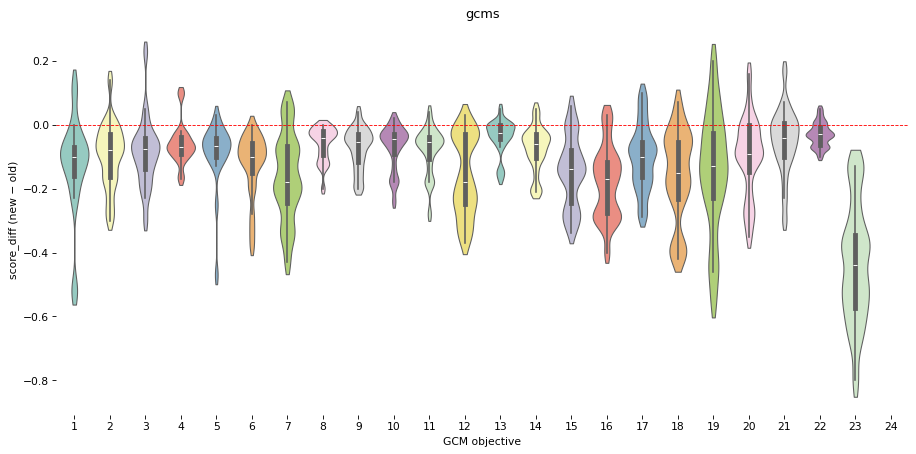

In [ ]:
#| eval: false
plot_score_diffs(dfs, 'gcms', 'GCM objective', figsize=(12, 6), dpi=77)

## Reporting

This section provides utilities for generating structured comparison reports between two versions of evaluation mappings (e.g. before and after a model update). Reports highlight themes that cross key relevance thresholds ("fundamental" themes), and surface reasoning changes side-by-side to support human review.

In [ ]:
#| export
def get_theme(
    result:dict, # loaded .json tagging result
    mapping_type, # 'gcms', 'enbs', 'ccps', 'outs'
    theme_id:str # theme ID
    ):
    "Get a single theme dict from a result by mapping_type and theme_id"
    return next((t for t in result['mappings'][mapping_type] if str(t['theme_id']) == str(theme_id)), None)

Retrieves a single theme entry from a loaded result by mapping type and theme ID. For instance:

In [ ]:
#| eval: false
old_r,new_r = load_result(evl, LATEST_TAG_PATH), load_result(evl, RESULTS_PATH)
get_theme(new_r, 'gcms', '1')

{'theme_id': '1',
 'theme_title': 'Collect and utilize accurate and disaggregated data as a basis for evidence-based policies',
 'relevance_score': 0.3,
 'reasoning': 'The excerpts contain limited but tangible references to data and information systems. The Migration Information and Data Analysis System (MIDAS) is mentioned as a specific activity under BMM Phase III, and digital data platforms (GIZ data platform and IOM SharePoint) are noted as improving monitoring and coordination. However, these references are brief and appear as examples within broader discussions of programme activities rather than as subjects of dedicated analysis. There is no substantive examination of data collection methodologies, disaggregation, or evidence-based policymaking processes that would align with the core actions under Objective 1. A synthesis specialist might note the MIDAS reference as a peripheral data point, but the report does not appear to offer meaningful evidence on this objective based on t

In [ ]:
#| export
def theme_md(
    mapping_type:str, # 'gcms', 'enbs', 'ccps', 'outs' 
    theme_id:str, # theme ID 
    old_r:dict, # old taggingresult 
    new_r:dict, # new tagging result
    row:pd.Series # row from df of delta between old and new
    ):
    "Render a single theme comparison as markdown with collapsible reasoning"
    o,n = get_theme(old_r, mapping_type, theme_id), get_theme(new_r, mapping_type, theme_id)
    return f"""#### {mapping_type.upper()} — {n['theme_id']}: {n['theme_title']}

| score_old | score_new | rank_old | rank_new | rank_diff |
|---|---|---|---|---|
| {row.score_old} | {row.score_new} | {row.rank_old} | {row.rank_new} | {row.rank_diff} |

<details><summary>Reasoning (old)</summary>{o['reasoning']}</details>

---

<details><summary>Reasoning (new)</summary>{n['reasoning']}</details>"""

Renders a side-by-side comparison of old vs. new scores, ranks, and reasoning for a single theme as markdown, with collapsible detail blocks for readability. 

For instance:

In [ ]:
#| eval: false
row = dfs[dfs.evl_id == evl].iloc[0]
print(theme_md(row.mapping_type, row.theme_id, old_r, new_r, row))

#### CCPS — 1: Integrity, Transparency and Accountability

| score_old | score_new | rank_old | rank_new | rank_diff |
|---|---|---|---|---|
| 0.48 | 0.52 | 2 | 2 | 0 |

<details><summary>Reasoning (old)</summary>This report contains some content that touches peripherally on accountability and transparency themes, but these are not primary evaluation foci. The evaluation examines IOM's coordination, reporting mechanisms, and monitoring systems within the BMM programme context. Findings note that 'reporting mechanisms were well-structured' and 'IOM's structured monitoring and reporting systems ensured accountability and adaptive management.' The report also discusses efficiency in coordination and financial management. However, integrity, transparency, and accountability are not evaluated as distinct institutional commitments—they appear as operational attributes when assessing programme efficiency. There is no dedicated analysis of IOM's accountability frameworks, transparency practice

In [ ]:
#| export
async def gen_report_cells(
    rpt_id,                        # report ID
    dfs,                           # combined deltas DataFrame from all_deltas
    old_results_path,              # path to old/backup results
    new_results_path,              # path to new results
    threshold=0.83,                # relevance score threshold for "fundamental"
    exclude_type='outs',           # mapping type to exclude from threshold checks
    plot_kwargs=None               # kwargs passed to plot_rank_changes (e.g. figsize, dpi)
):
    "Generate dialog cells comparing old vs new mappings for a report."
    old_r,new_r = load_result(rpt_id, old_results_path), load_result(rpt_id, new_results_path)
    mid = await add_msg(f"### {new_r['meta']['Title']}", placement='at_end')
    pkw = ifnone(plot_kwargs, dict(figsize=(12,6), dpi=77))
    mid = await add_msg(f"plot_rank_changes(dfs[dfs.evl_id == '{rpt_id}'], {', '.join(f'{k}={v}' for k,v in pkw.items())})", msg_type='code', run=False, placement='add_after', id=mid)
    df,seen = dfs[dfs.evl_id == rpt_id], set()
    filt = f'mapping_type != "{exclude_type}"'
    for q,label in [(df.query(f'score_old > {threshold} & {filt}'), 'Was Fundamental'),
                    (df.query(f'score_new > {threshold} & {filt}'), 'Is Now Fundamental')]:
        rows = [(row.mapping_type,str(row.theme_id),row) for _,row in q.iterrows() if (row.mapping_type,str(row.theme_id)) not in seen]
        if not rows: continue
        mid = await add_msg(f"**{label}**", placement='add_after', id=mid)
        for mt,tid,row in rows:
            seen.add((mt,tid))
            mid = await add_msg(theme_md(mt, tid, old_r, new_r, row), placement='add_after', id=mid)
    return mid

Orchestrates a full per-report comparison by generating a sequence of dialog messages: a title, a rank-change plot, and theme-level comparisons for all themes that were or have become "fundamental" (above a configurable relevance threshold) in either version. It leverages [SolveIt](https://solve.it.com) dialog engineering platform to generate ad hoc code and markdown cells.

For instance:

In [ ]:
#| eval: false
await gen_report_cells(evl, dfs, LATEST_TAG_PATH, RESULTS_PATH)

'_da52a9fa'

Can you suggest introduction lines, paragraph for the "Reporting" section and related functions on their purpose?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Here's a suggested introductory note for the **Reporting** section:

---

This section provides utilities for generating structured comparison reports between two versions of evaluation mappings (e.g. before and after a model update). Reports highlight themes that cross key relevance thresholds ("fundamental" themes), and surface reasoning changes side-by-side to support human review.

- **`get_theme`** — retrieves a single theme entry from a loaded result by mapping type and theme ID.
- **`theme_md`** — renders a side-by-side comparison of old vs. new scores, ranks, and reasoning for a single theme as markdown, with collapsible detail blocks for readability.
- **`gen_report_cells`** — orchestrates a full per-report comparison by generating a sequence of dialog messages: a title, a rank-change plot, and theme-level comparisons for all themes that were or have become "fundamental" (above a configurable relevance threshold) in either version.

<details class='token-usage-details'><summary>$0.0443</summary>

`total=35,708 | in=35,447 | out=261 | cached=84.3% | cache_new=5 | $0.0443`

</details>


### Final External Evaluation: Better Migration Management Programme Phase III

In [ ]:
plot_rank_changes(dfs[dfs.evl_id == '4341695461234eee3deb51ac68871109'], figsize=(12, 6), dpi=77)

**Was Fundamental**

#### GCMS — 10: Prevent, combat and eradicate trafficking in persons in the context of international migration

| score_old | score_new | rank_old | rank_new | rank_diff |
|---|---|---|---|---|
| 0.88 | 0.85 | 1 | 1 | 0 |

<details><summary>Reasoning (old)</summary>This report would likely be essential evidence for a synthesis on GCM Objective 10. Counter-trafficking is a core programme objective explicitly stated in the programme title and design. The overall BMM objective is to 'effectively address and reduce trafficking in human beings.' Component 2 focuses on 'effective institutions to address and reduce trafficking' with specific outputs on improving investigation quality and strengthening border cooperation on trafficking cases. Component 3 addresses 'Protection of victims of trafficking.' The findings confirm IOM met or exceeded targets in strengthening institutional capacities and improving victim protection. National Referral Mechanisms (NRMs) development is a specific deliverable. Key sections for review: Overall programme design, Component 2 and 3 intervention logic, findings on institutional capacity building, findings on victim protection, Recommendation 6 on NRM institutionalization. Directly relates to Actions 10b (implementation of global action plan), 10c (monitoring irregular routes), 10d (information sharing), 10e (measures addressing vulnerabilities), 10h (protection and assistance to victims), and 10i (training programmes).</details>

---

<details><summary>Reasoning (new)</summary>Based on the excerpts reviewed, this report would likely be essential for a synthesis on GCM Objective 10. Combating human trafficking is explicitly one of the two primary crime-related objectives of the BMM programme, appearing in the programme's overall objective statement and running through all three components. The evaluation examines IOM's contributions to anti-trafficking legislation, institutional capacity-building for identification and prosecution, victim protection services, and National Referral Mechanisms — directly relevant to Objective 10's associated actions on prosecution (10g), victim protection and assistance (10h), training and awareness (10i, 10j), and monitoring irregular routes exploited by trafficking networks (10c). The executive summary notes achievements in 'improving victim protection' and the conclusions discuss progress in protection services and cross-border cooperation. Recommendation 6 specifically addresses institutionalizing National Referral Mechanisms for trafficking victims. The evaluation covers multiple countries in the East and Horn of Africa, providing comparative evidence across different national contexts. Synthesis specialists should prioritize the effectiveness sections on protection outcomes, the findings on institutional capacity for victim identification and referral, and the sustainability analysis regarding NRM continuity — these appear to offer the most direct evidence on Objective 10 actions based on the excerpts reviewed.</details>

#### GCMS — 11: Manage borders in an integrated, secure and coordinated manner

| score_old | score_new | rank_old | rank_new | rank_diff |
|---|---|---|---|---|
| 0.85 | 0.82 | 2 | 2 | 0 |

<details><summary>Reasoning (old)</summary>This report would likely be essential evidence for a synthesis on GCM Objective 11. Component 2 explicitly focuses on 'strengthening the capacity of border authorities and immigration services' and 'integrated border governance.' The report discusses MIDAS border management systems, Inter-Agency Border Management Committees (IBMCs) in Somalia, and cross-border cooperation mechanisms. Findings note that IOM 'strengthened border management' and 'enhanced cross-border cooperation.' The Ethiopia-Kenya study tour on border management is highlighted as a best practice. The conflict response in Sudan required shifting focus to border management in South Sudan. Key sections for review: Component 2 intervention logic, findings on border management capacity building, impact section on IBMCs and cross-border cooperation, Recommendation 6 on strengthening cross-border mechanisms. Directly relates to Actions 11a (international cooperation on border management), 11b (efficient border procedures), 11e (child protection at borders), and 11g (cross-border collaboration).</details>

---

<details><summary>Reasoning (new)</summary>Based on the excerpts reviewed, this report would likely contribute substantial evidence to a synthesis on GCM Objective 11. Integrated border governance is explicitly Component 2 of the BMM programme, and the excerpts suggest the evaluation examines border management capacity-building, cross-border cooperation mechanisms, and training of border officials across multiple countries. The executive summary notes that IOM 'met or exceeded most programme targets' in 'strengthening institutional capacities' and 'enhanced migration governance,' with specific mention of Inter-Agency Border Management Committees (IBMCs) in Somalia as examples of improved operational coordination. The evaluation covers border management in Djibouti, Ethiopia, Kenya, Somalia, South Sudan, Sudan, and Uganda — providing multi-country evidence relevant to Objective 11's actions on international cooperation (11a), integrated border management structures (11b), and cross-border collaboration (11g). Training of border officials is specifically mentioned as surpassing targets. Synthesis specialists would likely want to review the effectiveness sections on border governance outcomes, the findings on IBMC functionality, and the recommendations on cross-border cooperation mechanisms. The conflict in Sudan and its effects on border management in South Sudan also provides evidence on adaptive border management in fragile contexts.</details>